# Styling, color and text

Everything about how a figure *looks*: the theme it is drawn with, the colors
and colormaps in it, the fonts, and the mathematics in its labels.

The organizing idea is that **none of it is global state.** There is no
`rcParams` and no `style.use()`. A `Theme` is an immutable object you pass to
`subplots`, a colormap is a value you pass to a mark, and a font preference is
the one process-wide setting there is — deliberately, because it is about the
machine rather than about the figure.

In [1]:
import math
import random

import pyplotrs as plt
from pyplotrs import color, colormaps, norms, palettes

plt.set_font_family("Liberation Sans")
random.seed(2)

t = [i * 0.15 for i in range(61)]
wave = [math.sin(x) for x in t]
damped = [math.sin(x) * math.exp(-0.2 * x) for x in t]
field = [[math.sin(0.22 * j) * math.cos(0.28 * i) + 0.4 * math.exp(-((i - 15) ** 2 + (j - 20) ** 2) / 60)
          for j in range(44)] for i in range(32)]

print(len(colormaps.available()), "colormaps ·", len(palettes.available()), "palettes")

127 colormaps · 25 palettes


## Themes

Five presets ship with the library. Each one is a complete set of decisions —
palette, spines, type scale, grid — not a color scheme bolted onto one base.

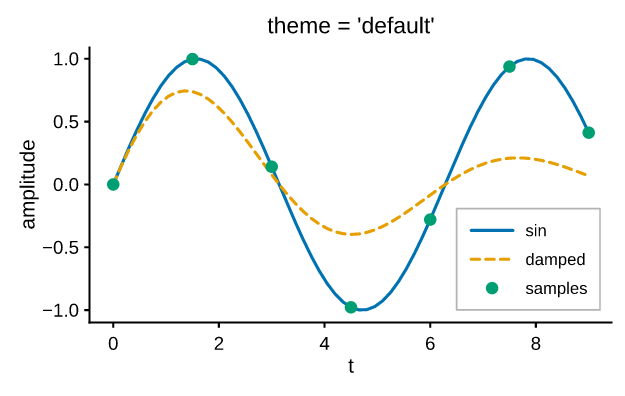

In [2]:
def demo(theme):
    """The same figure, drawn with whichever theme is passed in."""
    fig, ax = plt.subplots(figsize=(300, 190), theme=theme)
    ax.line(t, wave, label="sin")
    ax.line(t, damped, label="damped", linestyle="dashed")
    ax.scatter(t[::10], [wave[i] for i in range(0, len(t), 10)], label="samples")
    ax.set(title=f"theme = {theme!r}" if isinstance(theme, str) else "derived theme",
           xlabel="t", ylabel="amplitude")
    ax.legend(fontsize=8)
    return fig


demo("default")

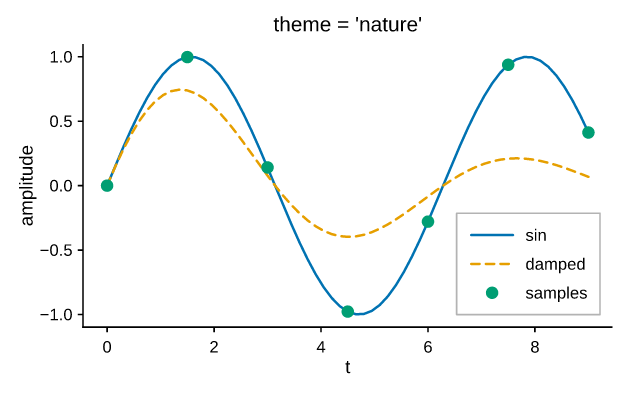

In [3]:
# `nature`: tuned for a printed journal column - smaller type, inward ticks.
demo("nature")

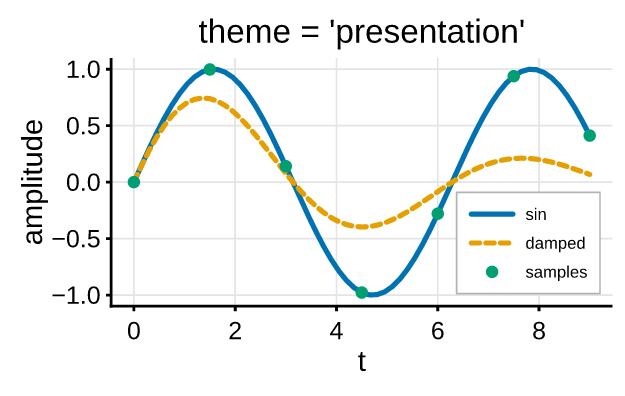

In [4]:
# `presentation`: heavier strokes and larger type, for a projector.
demo("presentation")

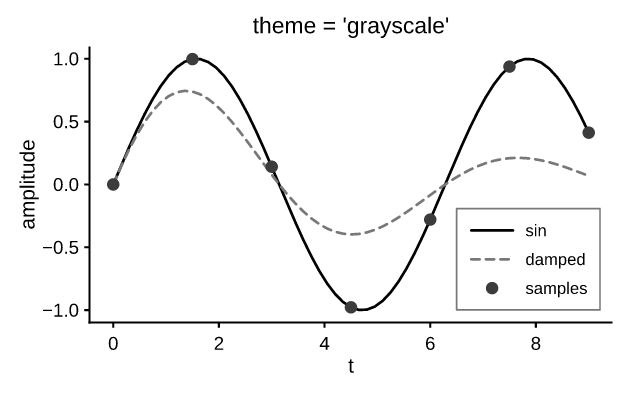

In [5]:
# `grayscale`: no color at all, for a figure that has to survive a mono printer.
# (`bw` is its stricter sibling: black only, distinguished by dash pattern.)
demo("grayscale")

### Deriving your own

`with_` returns a **new** theme with some fields replaced; the original is
untouched, so a derived theme can never leak back into whatever else is using
the base. Every field of `Theme` is available: `palette`, `spines`,
`spine_width`, `grid`, `grid_color`, `line_width`, the five type sizes, the
three weights, and the legend/axes fills.

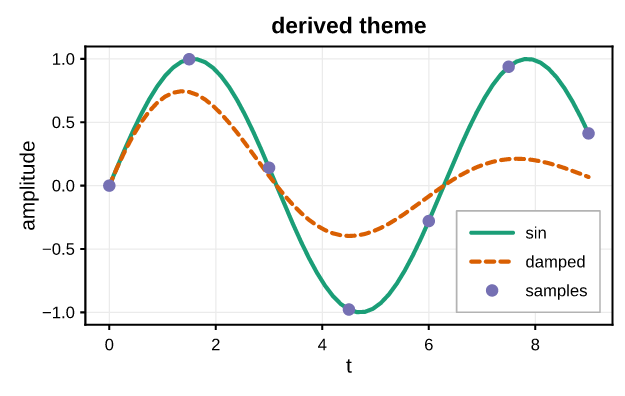

In [6]:
house_style = plt.themes.default.with_(
    palette=palettes.get("Dark2"),
    grid=True,
    grid_color=(235, 235, 235, 255),
    line_width=2.0,
    title_weight="bold",
    spines=("left", "bottom", "top", "right"),
    tick_label_size=8.0,
)

demo(house_style)

In [7]:
# A theme is a value, so two figures in one process - or one thread each - can
# hold different ones with nothing shared between them.
print("base palette :", plt.themes.default.palette[:3])
print("derived      :", house_style.palette[:3])
print("base untouched:", plt.themes.default.grid, "· derived:", house_style.grid)
print("built-ins    :", [n for n in ("default", "nature", "presentation", "bw",
                                     "grayscale")])

base palette : ((0, 114, 178, 255), (230, 159, 0, 255), (0, 158, 115, 255))
derived      : ((27, 158, 119, 255), (217, 95, 2, 255), (117, 112, 179, 255))
base untouched: False · derived: True
built-ins    : ['default', 'nature', 'presentation', 'bw', 'grayscale']


## Colors

Five spellings, all accepted anywhere a color is:

```python
color="C2"                  # index the ACTIVE theme's palette
color="steelblue"           # CSS / matplotlib color name
color="#4682b4"             # hex, with or without alpha
color=(0.27, 0.51, 0.71)    # floats in 0-1, matplotlib style
color=(70, 130, 180)        # bytes in 0-255, the native form
```

`"C0"`…`"Cn"` is the one worth changing your habits for: it indexes *this
figure's* palette rather than a fixed global cycle, so restyling a figure moves
every `"C3"` in it at once. The default palette is Okabe-Ito, which is designed
to stay distinguishable under the common color vision deficiencies.

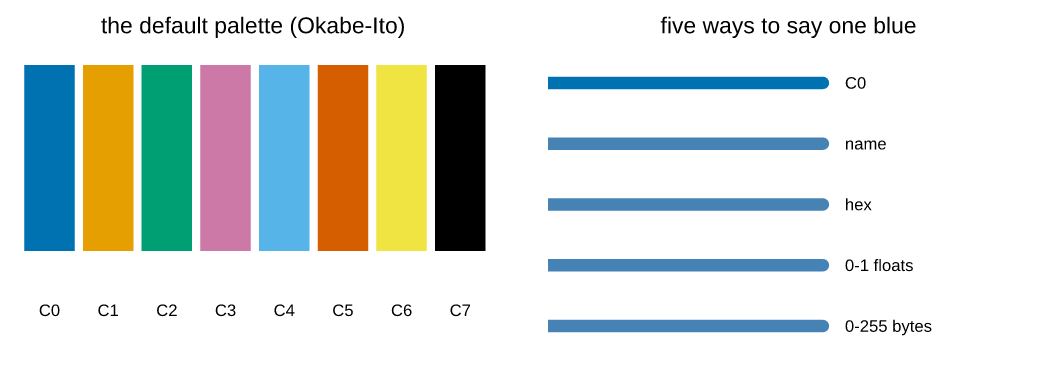

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(500, 180))

# The default palette, swatch by swatch.
okabe_ito = plt.themes.default.palette
for i in range(len(okabe_ito)):
    axs[0].rectangle((i, 0), 0.86, 1.0, facecolor=f"C{i}")
    axs[0].text(i + 0.43, -0.35, f"C{i}", ha="center", fontsize=8)
axs[0].set(title="the default palette (Okabe-Ito)", xlim=(-0.2, len(okabe_ito)),
           ylim=(-0.6, 1.1))
axs[0].axis("off")

# The same five spellings, all naming one blue.
spellings = [("C0", "C0"), ("name", "steelblue"), ("hex", "#4682b4"),
             ("0-1 floats", (0.27, 0.51, 0.71)), ("0-255 bytes", (70, 130, 180))]
for i, (spelling, value) in enumerate(spellings):
    row = len(spellings) - 1 - i          # first in the list, first on the page
    axs[1].line([0, 1], [row, row], color=value, linewidth=6)
    axs[1].text(1.08, row, spelling, va="center", fontsize=8)
axs[1].set(title="five ways to say one blue", xlim=(0, 1.75), ylim=(-0.6, 4.6))
axs[1].axis("off")

fig

## Fonts

`set_font_family` sets a preference order, once per process; the first face that
actually resolves wins, and the bundled Liberation Sans (compiled into the
extension) is the last resort that is always there. Whatever resolves is
**embedded in the output**, so the file looks the same on a machine that has
never heard of it.

In [9]:
print("preference :", plt.get_font_family())
print("resolved   :", plt.resolved_font_name())
print("variants   :", plt.resolved_font_variants())

# Ask for a list; the first face that is actually installed wins. On your own
# machine you would put Helvetica or Arial at the front of that list - here the
# first entry is deliberately a name nothing has, so the fallback is what the
# output shows on every machine.
plt.set_font_family(["No Such Face", "Liberation Sans"])
print("asked for a font that does not exist →", plt.resolved_font_name())

preference : ['Liberation Sans']
resolved   : Liberation Sans
variants   : [('body', 'LiberationSans'), ('body-bold', 'LiberationSans-Bold'), ('body-italic', 'LiberationSans-Italic'), ('body-bolditalic', 'LiberationSans-BoldItalic')]
asked for a font that does not exist → Liberation Sans


unicode_minus=True  → ['−3', '−2', '−1', '0', '1', '2', '3']
unicode_minus=False → ['-3', '-2', '-1', '0', '1', '2', '3']


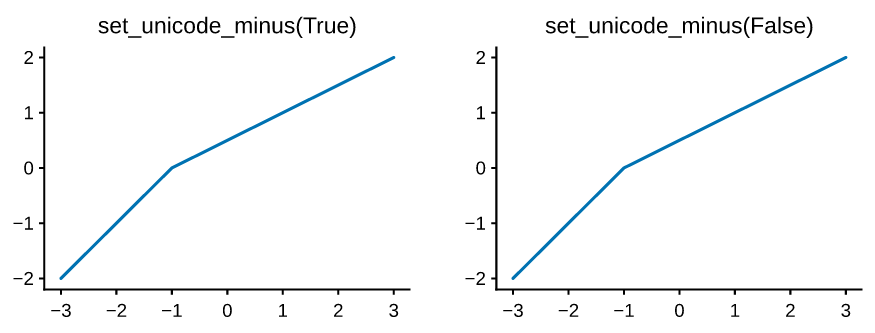

In [10]:
# Tick labels use a real U+2212 MINUS SIGN rather than the hyphen you typed.
fig, axs = plt.subplots(1, 2, figsize=(420, 160))
for ax, unicode_minus in zip(axs, (True, False)):
    plt.set_unicode_minus(unicode_minus)
    ax.line([-3, -1, 1, 3], [-2, 0, 1, 2])
    ax.set(title=f"set_unicode_minus({unicode_minus})")
    print(f"unicode_minus={unicode_minus!s:<5} → {ax.get_xticklabels()}")

plt.set_unicode_minus(True)
fig

## Mathematics

Anything between `$…$` is typeset by pyplotrs' own engine, from the math font's
OpenType MATH table. **No LaTeX installation is involved**, and the result stays
real, selectable text in PDF, SVG and HTML — not a picture of an equation.

Write the strings raw (`r"..."`) so Python leaves the backslashes alone.

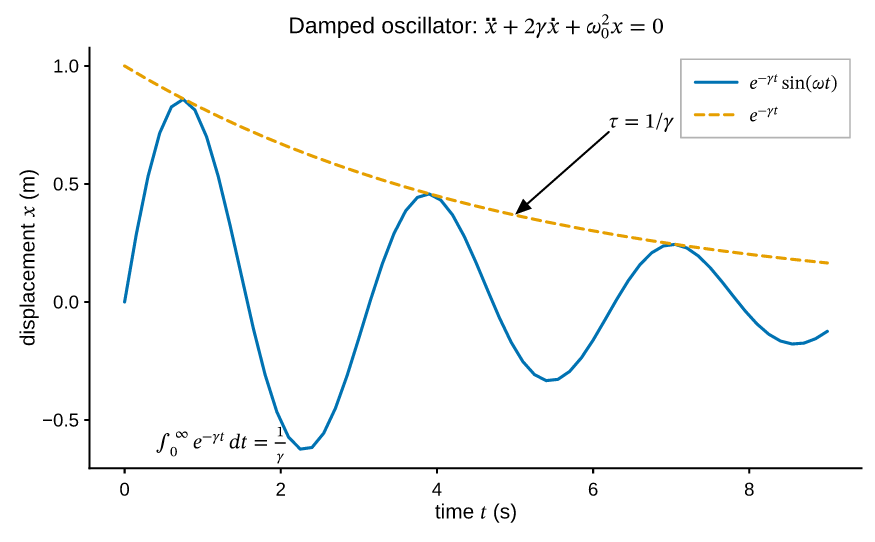

In [11]:
fig, ax = plt.subplots(figsize=(420, 260))

ax.line(t, [math.exp(-0.2 * x) * math.sin(2 * x) for x in t],
        label=r"$e^{-\gamma t}\sin(\omega t)$")
ax.line(t, [math.exp(-0.2 * x) for x in t], linestyle="dashed",
        label=r"$e^{-\gamma t}$")
ax.set(title=r"Damped oscillator: $\ddot{x} + 2\gamma\dot{x} + \omega_0^2 x = 0$",
       xlabel=r"time $t$ (s)", ylabel=r"displacement $x$ (m)")
ax.legend()

ax.annotate(r"$\tau = 1/\gamma$", (5.0, 0.37), xytext=(6.2, 0.72))
ax.text(0.4, -0.62, r"$\int_0^\infty e^{-\gamma t}\,dt = \frac{1}{\gamma}$",
        fontsize=10)
fig

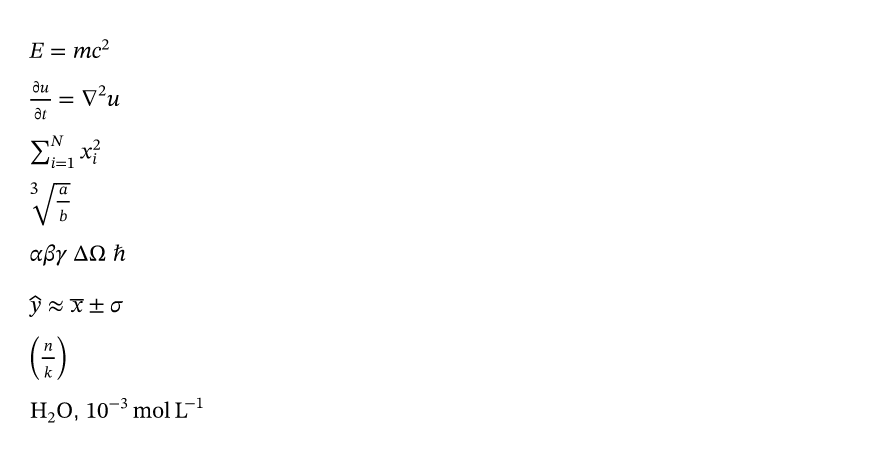

In [12]:
# A sampler of what the engine handles.
samples = [r"$E = mc^2$",
           r"$\frac{\partial u}{\partial t} = \nabla^2 u$",
           r"$\sum_{i=1}^{N} x_i^2$",
           r"$\sqrt[3]{\frac{a}{b}}$",
           r"$\alpha\beta\gamma\;\Delta\Omega\;\hbar$",
           r"$\hat{y} \approx \bar{x} \pm \sigma$",
           r"$\left(\frac{n}{k}\right)$",
           r"$\mathrm{H_2O}$, $10^{-3}\,\mathrm{mol\,L^{-1}}$"]

fig, ax = plt.subplots(figsize=(420, 220))
for i, expression in enumerate(samples):
    ax.text(0.02, len(samples) - i, expression, fontsize=11, va="center")
ax.set(xlim=(0, 1), ylim=(0.3, len(samples) + 0.7))
ax.axis("off")
fig

## Colormaps

127 colormaps ship with the library, in five families. `colormaps.available()`
lists them all; passing a category lists one family.

In [13]:
for category in colormaps.CATEGORIES:
    names = colormaps.available(category)
    print(f"{category:<21} {len(names):>3}  {', '.join(names[:7])} …")

perceptually_uniform    5  cividis, inferno, magma, plasma, viridis …
sequential             69  Blues, BuGn, BuPu, GnBu, Grays, Greens, Greys …
diverging              27  BrBG, PRGn, PiYG, PuOr, RdBu, RdGy, RdYlBu …
cyclic                  6  cet_colorwheel, cet_isolum, cmo_phase, hsv, twilight, twilight_shifted …
miscellaneous          20  CMRmap, brg, cet_rainbow, cet_rainbow4, cmo_topo, cubehelix, flag …


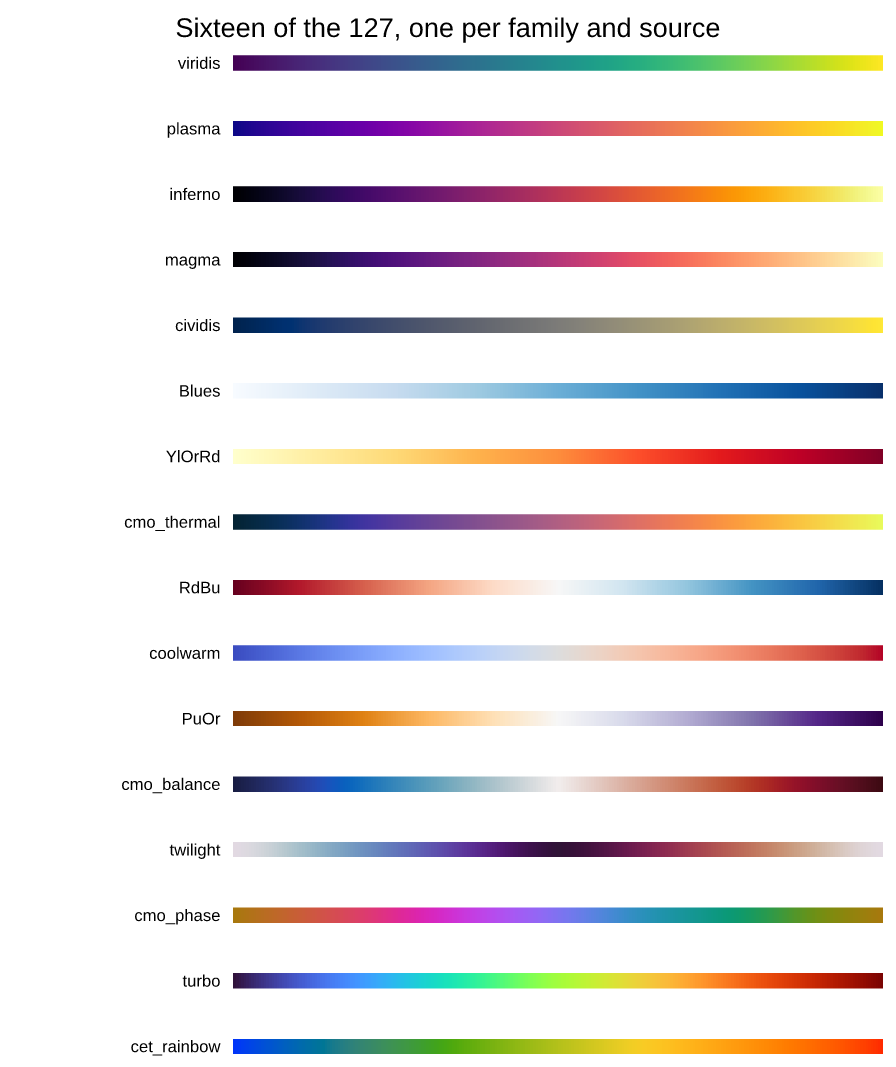

In [14]:
# A reference strip: one row per colormap, the unit interval left to right.
selection = ["viridis", "plasma", "inferno", "magma", "cividis",
             "Blues", "YlOrRd", "cmo_thermal",
             "RdBu", "coolwarm", "PuOr", "cmo_balance",
             "twilight", "cmo_phase",
             "turbo", "cet_rainbow"]
ramp = [[j / 255 for j in range(256)]]

fig, axs = plt.subplots(len(selection), 1, figsize=(430, 32 * len(selection)))
for ax, name in zip(axs, selection):
    ax.imshow(ramp, cmap=name, extent=(0, 1, 0, 1))
    ax.text(-0.02, 0.5, name, ha="right", va="center", fontsize=8)
    ax.set(xlim=(-0.34, 1.0), ylim=(0, 1))
    ax.axis("off")
fig.set(suptitle="Sixteen of the 127, one per family and source")
fig

viridis(0.0) = (68, 1, 84, 255)
viridis(0.5) = (33, 145, 140, 255)
viridis(1.0) = (253, 231, 37, 255)
reversed     = (253, 231, 37, 255) · by name: (253, 231, 37, 255)


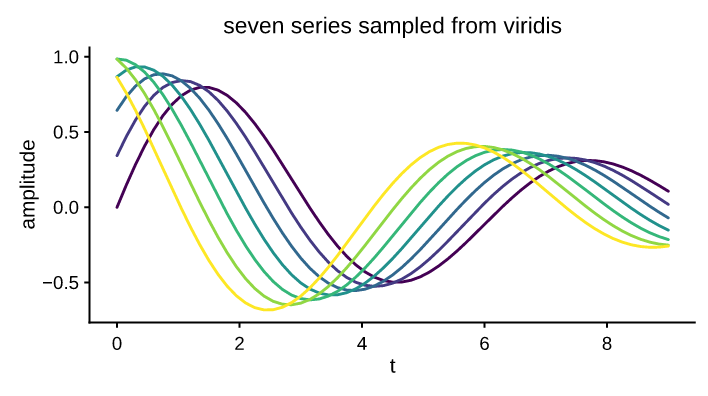

In [15]:
# A colormap is a callable: give it a position in [0, 1], get the RGBA back.
# `.reversed()` returns a new one; the "_r" name suffix works too.
viridis = colormaps.get_cmap("viridis")
print("viridis(0.0) =", viridis(0.0))
print("viridis(0.5) =", viridis(0.5))
print("viridis(1.0) =", viridis(1.0))
print("reversed     =", viridis.reversed()(0.0), "· by name:",
      colormaps.get_cmap("viridis_r")(0.0))

# So a discrete series can be sampled straight out of a continuous map.
fig, ax = plt.subplots(figsize=(340, 190))
for i in range(7):
    ax.line(t, [math.sin(x + i * 0.35) * math.exp(-0.15 * x) for x in t],
            color=viridis(i / 6), linewidth=1.4)
ax.set(title="seven series sampled from viridis", xlabel="t", ylabel="amplitude")
fig

### Norms: how a value becomes a position on the map

By default the data range maps linearly onto `[0, 1]`. A `norm` changes that
mapping, which is the difference between a readable image and a wash.

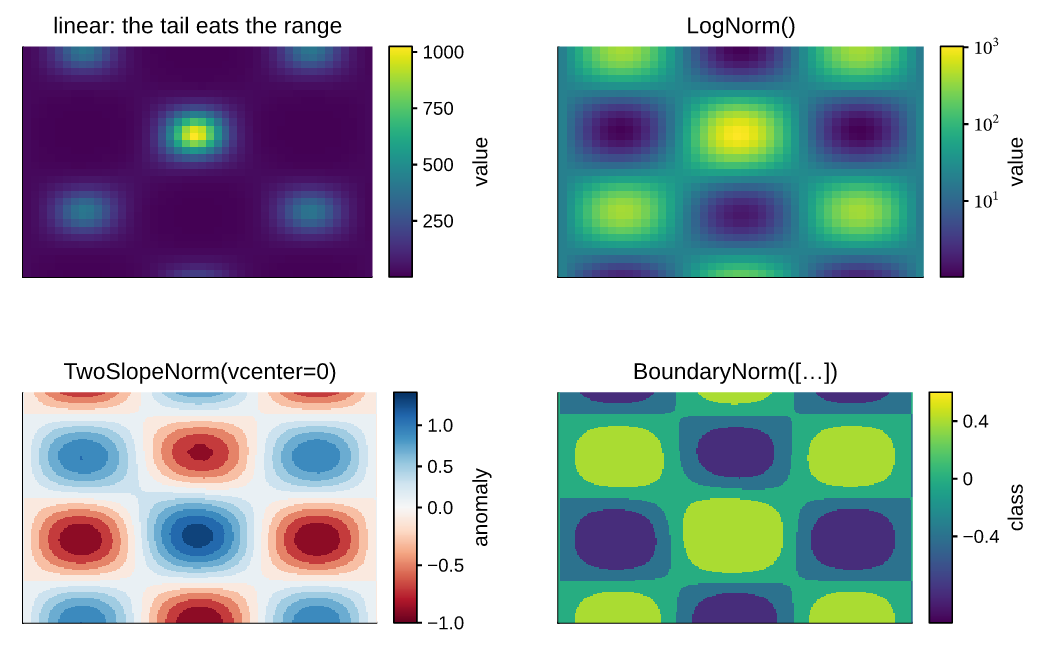

In [16]:
# One field with a long positive tail, and one signed field with a meaningful
# zero, so each norm has a job worth doing.
skewed = [[math.exp(3 * (v + 1)) for v in row] for row in field]

fig, axs = plt.subplots(2, 2, figsize=(500, 320))

a = axs[0][0].imshow(skewed, cmap="viridis")
fig.colorbar(a, label="value")
axs[0][0].set(title="linear: the tail eats the range", xticks=[], yticks=[])

b = axs[0][1].imshow(skewed, cmap="viridis", norm=norms.LogNorm())
fig.colorbar(b, label="value")
axs[0][1].set(title="LogNorm()", xticks=[], yticks=[])

# A diverging map is only honest when its middle sits on the reference value.
c = axs[1][0].contourf(field, levels=14, cmap="RdBu",
                       norm=norms.TwoSlopeNorm(vcenter=0.0, vmin=-1.0, vmax=1.4))
fig.colorbar(c, label="anomaly")
axs[1][0].set(title="TwoSlopeNorm(vcenter=0)", xticks=[], yticks=[])

# Boundaries turn a continuum into named classes, each with one flat color.
d = axs[1][1].contourf(field, levels=14, cmap="viridis",
                       norm=norms.BoundaryNorm([-1.0, -0.4, 0.0, 0.4, 1.4]))
fig.colorbar(d, label="class", ticks=[-0.4, 0.0, 0.4])
axs[1][1].set(title="BoundaryNorm([…])", xticks=[], yticks=[])

fig

## Color science

`pyplotrs.color` is the part that has no matplotlib equivalent: conversions to
perceptual spaces, a distance metric that matches what eyes do, and two
measurements you can run on a colormap *before* you publish with it.

In [17]:
teal = (0, 158, 115)

print("sRGB      ", teal)
print("Oklab     ", tuple(round(v, 4) for v in color.to_oklab(teal)))
print("Oklch     ", tuple(round(v, 3) for v in color.to_oklch(teal)))
print("CIE Lab   ", tuple(round(v, 2) for v in color.to_lab(teal)))
print("CAM16-UCS ", tuple(round(v, 2) for v in color.to_cam16ucs(teal)))
print("linear    ", tuple(round(v, 4) for v in color.to_linear(teal)))
print()

# `distance` is CAM16-UCS: "how different do these look", not "how far apart are
# the numbers". Two pairs with similar RGB gaps can be very different to look at.
orange, blue = (230, 159, 0), (0, 114, 178)
print("distance(orange, blue) =", round(color.distance(orange, blue), 1))
print("distance(orange, teal) =", round(color.distance(orange, teal), 1))

sRGB       (0, 158, 115)
Oklab      (0.6198, -0.1254, 0.0325)
Oklch      (0.62, 0.13, 165.459)
CIE Lab    (57.74, -45.74, 12.76)
CAM16-UCS  (58.94, 30.35, 167.56)
linear     (0.0, 0.3419, 0.1714)

distance(orange, blue) = 67.7
distance(orange, teal) = 47.4


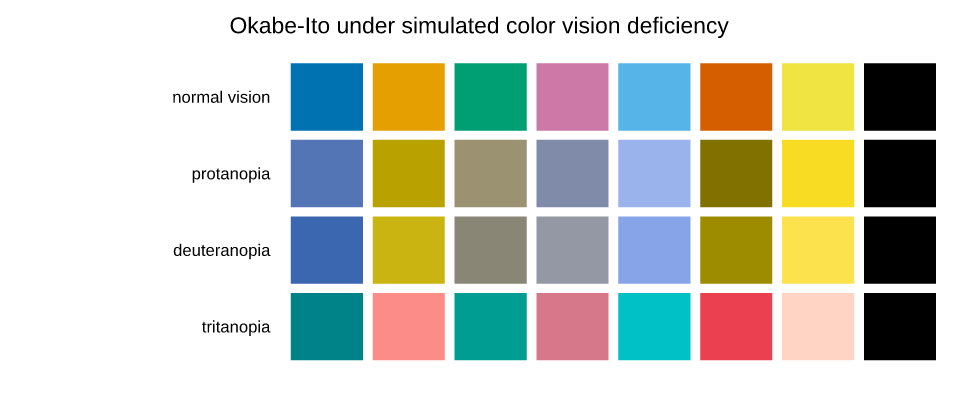

In [18]:
# How the palette reads to someone with each kind of dichromacy.
kinds = ["protanopia", "deuteranopia", "tritanopia"]
palette = plt.themes.default.palette

fig, ax = plt.subplots(figsize=(460, 190))
for row, kind in enumerate(["normal vision", *kinds]):
    for i, rgba in enumerate(palette):
        rgb = rgba[:3]
        shown = rgb if row == 0 else color.simulate_cvd(rgb, kinds[row - 1])
        ax.rectangle((i, -row), 0.88, 0.88, facecolor=shown)
    ax.text(-0.25, -row + 0.44, kind, ha="right", va="center", fontsize=8)
ax.set(xlim=(-3.4, len(palette)), ylim=(-3.3, 1.1),
       title="Okabe-Ito under simulated color vision deficiency")
ax.axis("off")
fig

In [19]:
# Two numbers worth checking before you commit to a colormap.
#
#   perceptual_uniformity  roughness of the CAM16-UCS step size: 0 is perfect,
#                          larger means some regions compress more data range
#                          into less visual change than others.
#   cvd_safe_report        worst-case distinguishability under each deficiency,
#                          1.0 = untouched, below ~0.5 = a real concern.
print(f"{'colormap':<16}{'roughness':>10}   protan  deuter  tritan")
for name in ["viridis", "cividis", "magma", "Blues", "RdBu", "turbo", "jet",
             "rainbow"]:
    roughness = color.perceptual_uniformity(name)
    report = color.cvd_safe_report(name)
    print(f"{name:<16}{roughness:>10.3f}   "
          + "  ".join(f"{report[k]:6.2f}" for k in kinds))

colormap         roughness   protan  deuter  tritan
viridis              0.246     0.39    0.58    0.54
cividis              0.277     0.90    0.91    0.64
magma                0.472     0.45    0.71    0.58
Blues                0.252     0.80    0.91    0.93
RdBu                 0.238     0.84    0.95    1.00
turbo                0.386     0.25    0.31    0.54
jet                  0.465     0.55    0.23    0.31
rainbow              0.398     0.32    0.12    0.49


The two columns measure different things, and a map can do well on one and badly
on the other:

- **Roughness** is about the data. `viridis`, `RdBu` and `Blues` step evenly
  (~0.24-0.25), so equal steps in the data look like equal steps in color.
  `jet` and `rainbow` are roughly twice as rough: they compress whole stretches
  of the range into one apparent color and expand others into false detail,
  which is how a rainbow-mapped image acquires bands that are not in the data.
- **CVD** is about the reader. `cividis` was built for it and shows it
  (0.90 / 0.91 / 0.64). `viridis` is smooth but loses roughly half its
  worst-case contrast under protanopia. `rainbow` under deuteranopia keeps
  0.12 — its distinctions are, for that reader, gone.

`cividis` is the safe default when you do not know who is reading; `viridis` is
the better *quantitative* map; `jet` and `rainbow` are not defensible as either.

Here is the same field under a uniform map and under `jet`, with the roughness
printed above:

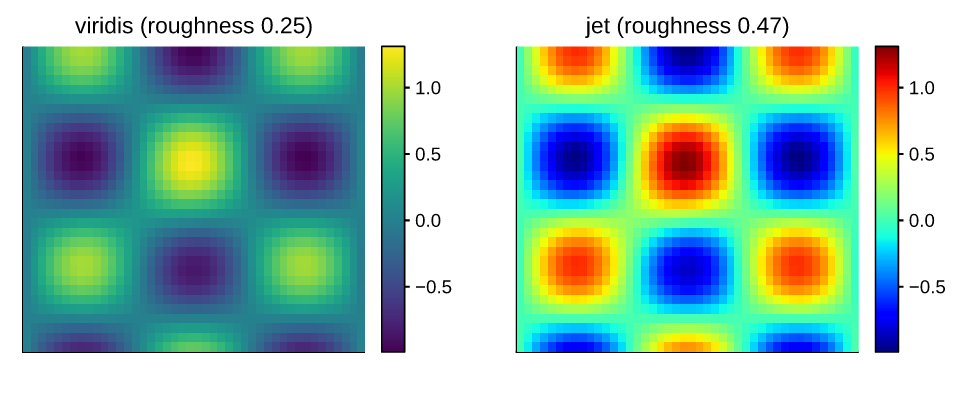

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(460, 190))
for ax, name in zip(axs, ("viridis", "jet")):
    mark = ax.imshow(field, cmap=name)
    fig.colorbar(mark)
    ax.set(title=f"{name} (roughness {color.perceptual_uniformity(name):.2f})",
           xticks=[], yticks=[])
fig

## Choosing

| The data is | Use a | For example |
|---|---|---|
| A magnitude with no meaningful middle | sequential, perceptually uniform map | `viridis`, `magma`, `cividis` |
| A deviation from a reference | diverging map + `TwoSlopeNorm` | `RdBu`, `PuOr`, `cmo_balance` |
| An angle or a phase | cyclic map | `twilight`, `cmo_phase` |
| A handful of unordered categories | the theme palette (`C0`…`Cn`) | Okabe-Ito, `Dark2` |
| Many unordered categories | a categorical palette built for it | `cet_glasbey` |
| Spanning several orders of magnitude | a uniform map + `LogNorm` | `viridis` |
| Classes, not a continuum | a uniform map + `BoundaryNorm` | `viridis` |

**Next:** [output formats and performance](06_output_and_performance.ipynb) —
what each file format guarantees, and how fast it gets written.